In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

# =========================
# LIBRERÍAS GENERALES
# =========================

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =========================
# PREPROCESAMIENTO
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================
# MODELOS
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# =========================
# MÉTRICAS
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# =========================
# BALANCEO DE DATOS
# =========================

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================
# IGNORAR WARNINGS (opcional)
# =========================

import warnings
warnings.filterwarnings("ignore")

# =========================
# CARGA DE DATOS
# =========================

path = "/content/drive/MyDrive/Colab Notebooks/TPS ANDREA/Anonymize_Loan_Default_data.csv"

df = pd.read_csv(path, encoding='latin1')

df.head()

In [ ]:
df.info()
df.columns

In [ ]:
df.describe().T


In [ ]:
# ==============================
# Análisis de valores faltantes
# ==============================

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Valores faltantes': missing_count,
    'Porcentaje (%)': missing_percent
})

missing_table = missing_table[missing_table['Valores faltantes'] > 0] \
    .sort_values(by='Porcentaje (%)', ascending=False)

print("Valores faltantes por variable:\n")
display(missing_table)

Valores faltantes por variable:



,Valores faltantes,Porcentaje (%)
next_pymnt_d,35097,91.208420
mths_since_last_delinq,24363,63.313410
emp_length,993,2.580561
last_pymnt_d,71,0.184511
revol_util,59,0.153326
revol_bal,4,0.010395
last_credit_pull_d,3,0.007796
annual_inc,2,0.005198
loan_amnt,1,0.002599
funded_amnt,1,0.002599


Se analizó la presencia de valores faltantes en el dataset con el objetivo de identificar posibles problemas de calidad de datos.
Se observa que algunas variables presentan una cantidad significativa de valores nulos, como mths_since_last_delinq y next_pymnt_d, lo cual deberá ser considerado en la etapa de preprocesamiento.
Otras variables presentan pocos valores faltantes, por lo que podrán ser imputadas sin generar un impacto significativo en el modelo.

In [ ]:
# ==============================
# Análisis de registros duplicados
# ==============================

duplicates = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicates}")

Cantidad de registros duplicados: 0


In [ ]:
df['repay_fail'].value_counts()

,count
repay_fail,
0,32651
1,5829


In [ ]:
# ==============================
# Distribución de la variable objetivo
# ==============================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='repay_fail',
    hue='repay_fail',
    palette='viridis',
    legend=False
)

plt.title('Distribución de Default (repay_fail)')
plt.xlabel('Default')
plt.ylabel('Cantidad de clientes')

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='repay_fail', palette='viridis')

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribución de Default (repay_fail)')
plt.xlabel('Default')
plt.ylabel('Cantidad de clientes')

plt.show()

In [ ]:
(df['repay_fail'].value_counts(normalize=True) * 100).round(2)

Se analizó la distribución de la variable objetivo repay_fail, la cual indica si un cliente incurrió en incumplimiento de pago (default).
Se observa un desbalance significativo entre las clases, con una mayor proporción de clientes que no presentan incumplimiento respecto a aquellos que sí lo presentan.
Este desbalance deberá ser considerado en etapas posteriores del modelado para evitar sesgos en la predicción.

In [ ]:
df.dtypes

In [ ]:
# =========================
# Eliminación de columnas innecesarias
# =========================

# Columnas identificadoras o sin valor predictivo
cols_to_drop = ['Unnamed: 0', 'id', 'member_id', 'zip_code']

df_model = df.copy()
df_model= df.drop(columns=cols_to_drop)

print("Columnas eliminadas correctamente.")
print("\nDimensión del dataset:", df.shape)

Se eliminaron variables identificadoras que no aportan información predictiva al modelo, tales como identificadores únicos de clientes y códigos postales. Estas variables pueden introducir ruido en el análisis y afectar el rendimiento de los algoritmos.

In [ ]:
cols_leakage = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'last_pymnt_amnt',
    'loan_status'
]
df_model = df_model.drop(columns=cols_leakage, errors='ignore')

In [ ]:
df_model.dtypes

Durante la etapa de preparación de datos se detectaron inconsistencias en el formato de algunas variables, particularmente en la variable de utilización de crédito rotativo, que presentaba caracteres especiales y símbolos de porcentaje. Se realizó una limpieza y conversión a formato numérico para asegurar la correcta interpretación de los valores. Asimismo, las variables temporales fueron transformadas al tipo fecha para permitir futuras transformaciones derivadas.

In [ ]:
# =========================
# PORCENTAJE DE VALORES FALTANTES
# =========================

missing_percent = df_model.isnull().mean() * 100

missing_df = (
    missing_percent
    .sort_values(ascending=False)
    .to_frame(name='missing_percent')
)

missing_df.head(20)

Se analizó la presencia de valores faltantes en las variables del dataset con el objetivo de identificar posibles problemas de calidad de datos. Este análisis permite definir estrategias de tratamiento adecuadas en etapas posteriores del preprocesamiento.

In [ ]:
# =========================
# ELIMINAR VARIABLES CON EXCESO DE MISSING
# =========================

cols_to_drop_missing = [
    'issue_d',
    'last_credit_pull_d',
    'last_pymnt_d',
    'next_pymnt_d'
]

df_model = df_model.drop(columns=cols_to_drop_missing)

print("Columnas eliminadas por alto porcentaje de missing")

Se identificaron variables con un porcentaje extremadamente alto de valores faltantes (superior al 99%), por lo que fueron eliminadas del análisis debido a la imposibilidad de recuperar información confiable mediante imputación. Esta decisión permite reducir ruido en los datos y mejorar la calidad del modelado posterior.

In [ ]:
df_model.head()

In [ ]:
# =========================
# CONVERTIR earliest_cr_line A FECHA
# =========================

df_model['earliest_cr_line'] = pd.to_datetime(
    df_model['earliest_cr_line'],
    format='%b-%y',
    errors='coerce'
)

print("Conversión de variables completada correctamente")

In [ ]:
df_model['revol_util'] = pd.to_numeric(
    df_model['revol_util']
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace('[^0-9.]', '', regex=True),
    errors='coerce'
)

In [ ]:
df_model['revol_util'].dtype

In [ ]:
df_model['revol_util'].head(20)

In [ ]:
df_model['revol_util'].isna().mean()

In [ ]:
# =========================
# CONVERSION DE TERM A TERM_MONTHS PARA PODER HACERLA UNA VBLE NUMERICA
# =========================
df_model['term'] = (
    df_model['term']
    .str.extract('(\d+)')
    .astype(int)
)
df_model = df_model.rename(columns={'term': 'term_months'})

In [ ]:
df_model.head()

In [ ]:
numeric_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

numeric_cols.remove('repay_fail')

In [ ]:
# =========================
# SEPARACIÓN FINAL DE VARIABLES
# =========================

# Variables fecha
date_cols = df_model.select_dtypes(include=['datetime64[ns]']).columns.tolist()

# Variables numéricas
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables categóricas
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

# Quitar target de numéricas
numeric_cols.remove('repay_fail')

print("Variables numéricas:", len(numeric_cols))
print("Variables categóricas:", len(categorical_cols))
print("Variables fecha:", len(date_cols))

Se realizó la clasificación de variables en tres grupos principales: variables numéricas, categóricas y temporales. La separación de las variables temporales permite la generación de atributos derivados en etapas posteriores, lo cual puede aportar información relevante para la predicción del incumplimiento de pago.

In [ ]:
# =========================
# BOXPLOTS VARIABLES NUMÉRICAS VS TARGET
# =========================

import math

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        data=df_model,
        x='repay_fail',
        y=col,
        hue='repay_fail',
        palette='viridis',
        legend=False
    )

    plt.title(f'{col} vs Repay Fail')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# BOXPLOTS CON ESCALA LOG (MEJOR VISUALIZACIÓN)
# =========================

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        data=df_model,
        x='repay_fail',
        y=col,
        hue='repay_fail',
        palette='viridis',
        legend=False
    )

    plt.yscale('log')  # escala logarítmica

    plt.title(f'{col} vs Repay Fail')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_model[numeric_cols].corr(),
    cmap='coolwarm',
    center=0,
    annot=True,          # muestra los valores
    fmt=".2f",           # 2 decimales
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación - Variables numéricas")
plt.show()

In [ ]:
corr_target = df_model[numeric_cols].corrwith(df_model['repay_fail'])

plt.figure(figsize=(8,6))
corr_target.sort_values().plot(kind='barh')
plt.title("Correlación con repay_fail")
plt.show()

In [ ]:
cols_dudosas = [
    'funded_amnt',
    'funded_amnt_inv'
]
df_model = df_model.drop(columns=cols_dudosas, errors='ignore')

Asimismo, se evaluó la eliminación de variables como funded_amnt y funded_amnt_inv, por alta colinealidad.

In [ ]:
# =========================
# CATEGÓRICAS VS TARGET
# =========================

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.countplot(
        data=df_model,
        x=col,
        hue='repay_fail',
        palette='viridis'
    )

    plt.title(f'{col} vs Repay Fail')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# FEATURE ENGINEERING FECHA
# =========================

df_model['credit_history_years'] = (
    (pd.Timestamp('today') - df_model['earliest_cr_line'])
    .dt.days / 365
)

# Rellenar posibles NaN con mediana
df_model['credit_history_years'] = df_model['credit_history_years'].fillna(
    df_model['credit_history_years'].median()
)

print("Variable credit_history_years creada correctamente")

In [ ]:
df_model = df_model.drop(columns=['earliest_cr_line'])

In [ ]:

y = df_model['repay_fail']
X = df_model.drop(columns=['repay_fail'])

print("Shape X:", X.shape)
print("Shape y:", y.shape)

In [ ]:
# =========================
# DIVISIÓN TRAIN / TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

In [ ]:
# =========================
# IDENTIFICACIÓN DE VARIABLES
# =========================

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Variables numéricas:", len(numeric_cols))
print("Variables categóricas:", len(categorical_cols))

In [ ]:
# =========================
# PIPELINE DE PREPROCESAMIENTO
# =========================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Pipeline de preprocesamiento creado")

In [ ]:
# =========================
# MODELO REGRESIÓN LOGÍSTICA
# =========================

logreg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

print("Modelo entrenado correctamente")

In [ ]:
# =========================
# PREDICCIONES
# =========================

y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]


# =========================
# MÉTRICAS
# =========================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Resultados - Regresión Logística")
print("---------------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")

In [ ]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
X.columns

In [ ]:
class_weight='balanced'

In [ ]:
# =========================
# MODELO: REGRESIÓN LOGÍSTICA BALANCEADA
# =========================

logreg_bal_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Entrenamiento
logreg_bal_pipeline.fit(X_train, y_train)

# Predicciones
y_pred_bal = logreg_bal_pipeline.predict(X_test)
y_proba_bal = logreg_bal_pipeline.predict_proba(X_test)[:, 1]

# =========================
# MÉTRICAS
# =========================

acc_bal = accuracy_score(y_test, y_pred_bal)
prec_bal = precision_score(y_test, y_pred_bal)
rec_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_bal = roc_auc_score(y_test, y_proba_bal)

print("Resultados - Regresión Logística Balanceada")
print("---------------------------------")
print(f"Accuracy : {acc_bal:.3f}")
print(f"Precision: {prec_bal:.3f}")
print(f"Recall   : {rec_bal:.3f}")
print(f"F1-score : {f1_bal:.3f}")
print(f"ROC AUC  : {roc_bal:.3f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_bal)
axes[0].plot(fpr, tpr, label='Logística Balanceada')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión')

plt.tight_layout()
plt.show()

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# =========================
# MODELO: REGRESIÓN LOGÍSTICA + SMOTE
# =========================

logreg_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

# Entrenamiento
logreg_smote_pipeline.fit(X_train, y_train)

# Predicciones
y_pred_smote = logreg_smote_pipeline.predict(X_test)
y_proba_smote = logreg_smote_pipeline.predict_proba(X_test)[:, 1]

# =========================
# MÉTRICAS
# =========================

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
roc_smote = roc_auc_score(y_test, y_proba_smote)

print("Resultados - Regresión Logística con SMOTE")
print("---------------------------------")
print(f"Accuracy : {acc_smote:.3f}")
print(f"Precision: {prec_smote:.3f}")
print(f"Recall   : {rec_smote:.3f}")
print(f"F1-score : {f1_smote:.3f}")
print(f"ROC AUC  : {roc_smote:.3f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_smote)
axes[0].plot(fpr, tpr, label='Logística + SMOTE')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# MODELO DUMMY CLASSIFIER
# =========================

dummy_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

# Entrenamiento
dummy_model.fit(X_train, y_train)

# Predicciones
y_pred_dummy = dummy_model.predict(X_test)

# Probabilidades (necesario para ROC)
y_proba_dummy = dummy_model.predict_proba(X_test)[:,1]

# Métricas
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
precision_dummy = precision_score(y_test, y_pred_dummy, zero_division=0)
recall_dummy = recall_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print("\nResultados - Dummy Model")
print("---------------------------------")
print("Accuracy :", round(accuracy_dummy,3))
print("Precision:", round(precision_dummy,3))
print("Recall   :", round(recall_dummy,3))
print("F1-score :", round(f1_dummy,3))
print("ROC AUC  :", round(roc_auc_dummy,3))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dummy)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - Dummy')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_dummy)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_dummy:.3f}")
axes[1].plot([0,1],[0,1],'--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - Dummy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# RANDOM FOREST
# =========================


rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Entrenamiento
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Probabilidades para ROC
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

# Métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("\nResultados - Random Forest")
print("---------------------------------")
print("Accuracy :", round(accuracy_rf,3))
print("Precision:", round(precision_rf,3))
print("Recall   :", round(recall_rf,3))
print("F1-score :", round(f1_rf,3))
print("ROC AUC  :", round(roc_auc_rf,3))

In [ ]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - Random Forest')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_rf:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# XGBOOST
# =========================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

# Entrenamiento
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Probabilidades
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

# Métricas
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("\nResultados - XGBoost")
print("---------------------------------")
print("Accuracy :", round(accuracy_xgb,3))
print("Precision:", round(precision_xgb,3))
print("Recall   :", round(recall_xgb,3))
print("F1-score :", round(f1_xgb,3))
print("ROC AUC  :", round(roc_auc_xgb,3))

In [ ]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - XGBoost')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_xgb:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - XGBoost')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# TABLA COMPARATIVA DE MODELOS
# =========================

import pandas as pd

resultados = pd.DataFrame({

    "Modelo": [
        "Dummy",
        "Regresión Logística",
        "Logística Balanceada",
        "Logística + SMOTE",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_dummy,
        accuracy,
        acc_bal,
        acc_smote,
        accuracy_rf,
        accuracy_xgb
    ],

    "Precision": [
        precision_dummy,
        precision,
        prec_bal,
        prec_smote,
        precision_rf,
        precision_xgb
    ],

    "Recall": [
        recall_dummy,
        recall,
        rec_bal,
        rec_smote,
        recall_rf,
        recall_xgb
    ],

    "F1-score": [
        f1_dummy,
        f1,
        f1_bal,
        f1_smote,
        f1_rf,
        f1_xgb
    ],

    "ROC AUC": [
        None,   # Dummy no tiene probabilidades útiles
        roc_auc,
        roc_bal,
        roc_smote,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

resultados = resultados.round(3)

resultados

In [ ]:
# =========================
# DEFAULT RATE SEGÚN MONTO DEL PRÉSTAMO
# =========================

import pandas as pd

# Crear bins de monto
df['loan_amnt_bin'] = pd.qcut(df['loan_amnt'], q=5)

default_rate = df.groupby('loan_amnt_bin')['repay_fail'].mean()

print(default_rate)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x=default_rate.index.astype(str),
    y=default_rate.values
)

plt.xticks(rotation=45)
plt.xlabel("Rango de monto del préstamo")
plt.ylabel("Tasa de incumplimiento")
plt.title("Incumplimiento según monto del préstamo")

plt.show()

Analizamos cuántos prestamos se otorgan con un monto mayor a 16000 vs menor a 16000

In [ ]:
df_model['loan_segment'] = (df_model['loan_amnt'] >= 16000)
df_model['loan_segment'].value_counts()

In [ ]:
# =========================
# SEGMENTACIÓN POR MONTO DE PRÉSTAMO
# =========================

df_low = df_model[df_model['loan_amnt'] < 16000].copy()
df_high = df_model[df_model['loan_amnt'] >= 16000].copy()

print("Dataset préstamos bajos:", df_low.shape)
print("Dataset préstamos altos:", df_high.shape)

In [ ]:
# =========================
# MODELO 1 - PRÉSTAMOS BAJOS
# =========================

y_low = df_low['repay_fail']
X_low = df_low.drop(columns=['repay_fail'])

# =========================
# MODELO 2 - PRÉSTAMOS ALTOS
# =========================

y_high = df_high['repay_fail']
X_high = df_high.drop(columns=['repay_fail'])

In [61]:
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    X_low,
    y_low,
    test_size=0.2,
    stratify=y_low,
    random_state=42
)

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    X_high,
    y_high,
    test_size=0.2,
    stratify=y_high,
    random_state=42
)

In [62]:
print("Default rate préstamos bajos:")
print(df_low['repay_fail'].mean())

print("\nDefault rate préstamos altos:")
print(df_high['repay_fail'].mean())

Default rate préstamos bajos:
0.14294288286485946

Default rate préstamos altos:
0.18166823751178135


In [63]:
X_train_low.select_dtypes(include="object").columns

Index(['emp_length', 'home_ownership', 'verification_status', 'purpose',
       'addr_state'],
      dtype='object')

**<h2>PRESTAMOS BAJOS</h2>**
<h3>Regresión Logística</h3>


In [64]:
# Pipeline
pipe_log_low = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
# Entrenar
pipe_log_low.fit(X_train_low, y_train_low)

#predicciones
y_pred_log_low = pipe_log_low.predict(X_test_low)
y_proba_log_low = pipe_log_low.predict_proba(X_test_low)[:,1]

# Métricas
accuracy_log_low = accuracy_score(y_test_low, y_pred_log_low)
precision_log_low = precision_score(y_test_low, y_pred_log_low)
recall_log_low = recall_score(y_test_low, y_pred_log_low)
f1_log_low = f1_score(y_test_low, y_pred_log_low)
roc_auc_log_low = roc_auc_score(y_test_low, y_proba_log_low)

print("Resultados - Regresión Logística (Préstamos bajos)")
print("Accuracy:", accuracy_log_low)
print("Precision:", precision_log_low)
print("Recall:", recall_log_low)
print("F1:", f1_log_low)
print("ROC AUC:", roc_auc_log_low)

Resultados - Regresión Logística (Préstamos bajos)
Accuracy: 0.6536089348224704
Precision: 0.23819742489270387
Recall: 0.6468531468531469
F1: 0.3481806775407779
ROC AUC: 0.7077775042178854


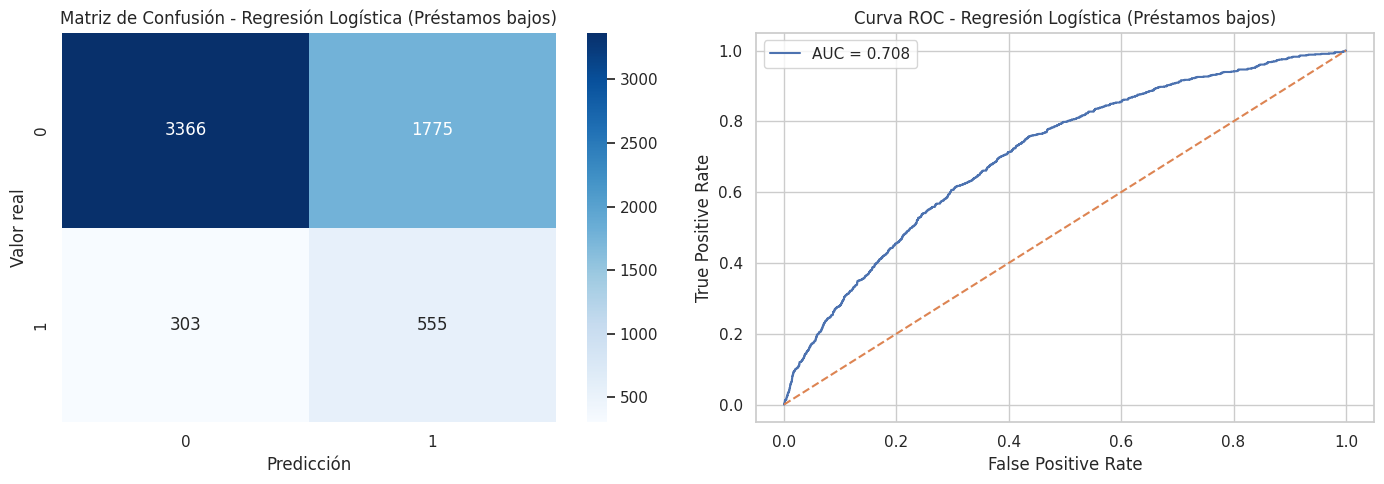

In [65]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test_low, y_pred_log_low)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - Regresión Logística (Préstamos bajos)')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test_low, y_proba_log_low)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_log_low:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - Regresión Logística (Préstamos bajos)')
axes[1].legend()

plt.tight_layout()
plt.show()

<h3>XGBoost</h3>

In [66]:
# Calcular peso para balancear clases
neg, pos = np.bincount(y_train_low)
scale_pos_weight = neg / pos

# Pipeline con preprocesamiento
pipe_xgb_low = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Entrenar modelo
pipe_xgb_low.fit(X_train_low, y_train_low)

# Predicciones
y_pred_xgb_low = pipe_xgb_low.predict(X_test_low)
y_proba_xgb_low = pipe_xgb_low.predict_proba(X_test_low)[:,1]

# =========================
# MÉTRICAS
# =========================

roc_auc_xgb_low = roc_auc_score(y_test_low, y_proba_xgb_low)

print("Resultados - XGBoost Balanceado (Préstamos bajos)")
print("Accuracy:", accuracy_score(y_test_low, y_pred_xgb_low))
print("Precision:", precision_score(y_test_low, y_pred_xgb_low))
print("Recall:", recall_score(y_test_low, y_pred_xgb_low))
print("F1:", f1_score(y_test_low, y_pred_xgb_low))
print("ROC AUC:", roc_auc_xgb_low)

Resultados - XGBoost Balanceado (Préstamos bajos)
Accuracy: 0.6896149358226371
Precision: 0.24569402228976697
Recall: 0.5652680652680653
F1: 0.3425141242937853
ROC AUC: 0.7072124367883947


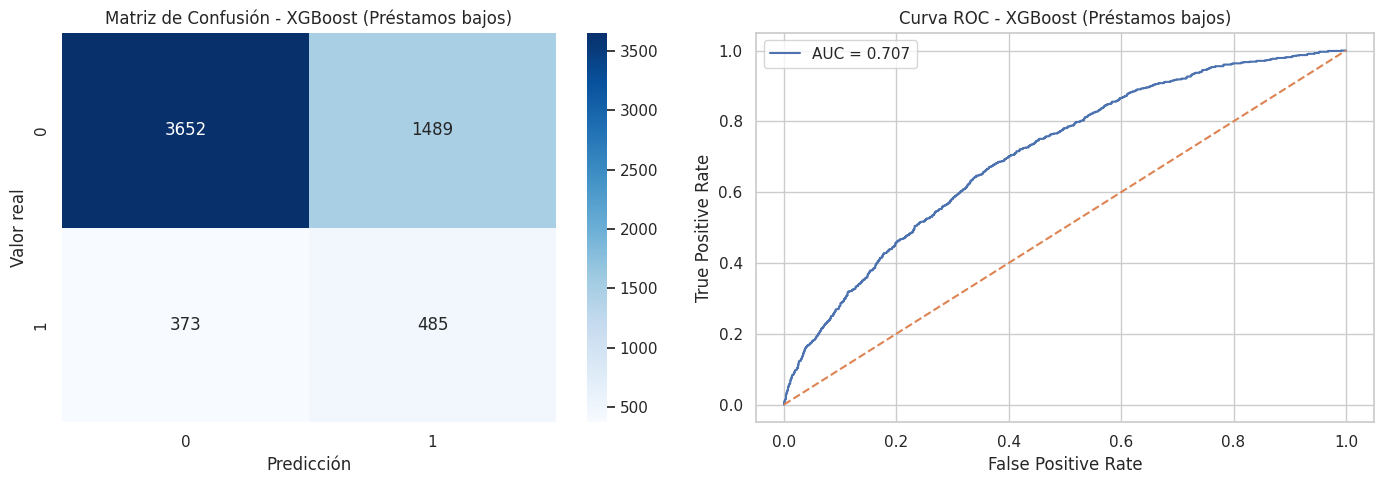

In [67]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test_low, y_pred_xgb_low)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - XGBoost (Préstamos bajos)')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test_low, y_proba_xgb_low)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_xgb_low:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - XGBoost (Préstamos bajos)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [68]:
%who

ColumnTransformer	 DecisionTreeClassifier	 DummyClassifier	 ImbPipeline	 KNeighborsClassifier	 LogisticRegression	 OneHotEncoder	 Pipeline	 RandomForestClassifier	 
SMOTE	 SimpleImputer	 StandardScaler	 X	 XGBClassifier	 X_high	 X_low	 X_test	 X_test_high	 
X_test_low	 X_train	 X_train_high	 X_train_low	 acc_bal	 acc_smote	 accuracy	 accuracy_dummy	 accuracy_log_low	 
accuracy_rf	 accuracy_score	 accuracy_xgb	 ax	 axes	 categorical_cols	 categorical_transformer	 class_weight	 classification_report	 
cm	 col	 cols_dudosas	 cols_leakage	 cols_to_drop	 cols_to_drop_missing	 confusion_matrix	 corr_target	 date_cols	 
default_rate	 df	 df_high	 df_low	 df_model	 drive	 dummy_model	 duplicates	 f1	 
f1_bal	 f1_dummy	 f1_log_low	 f1_rf	 f1_score	 f1_smote	 f1_xgb	 fig	 fpr	 
i	 logreg_bal_pipeline	 logreg_pipeline	 logreg_smote_pipeline	 math	 missing_count	 missing_df	 missing_percent	 missing_table	 
n_cols	 n_rows	 neg	 np	 numeric_cols	 numeric_transformer	 p	 path	 pd	 
percentage	 pipe_

**<h3>IMPORTANCIA DE VARIABLES</h3>**

<h3>REGRESIÓN LOGÍSTICA</h3>

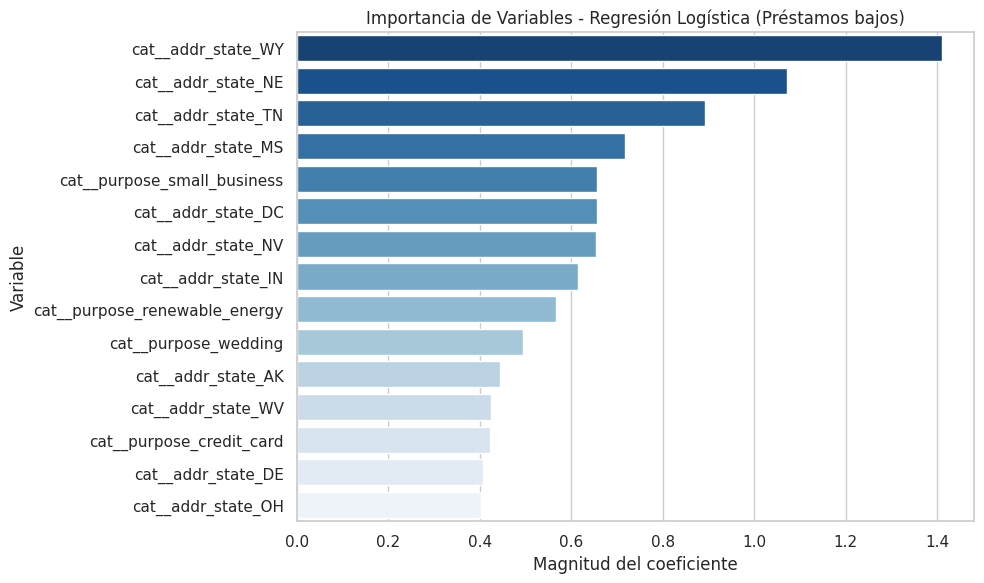

In [69]:
# Obtener nombres de variables después del preprocesamiento
feature_names = preprocessor.get_feature_names_out()

# Obtener coeficientes desde el modelo dentro del pipeline
coefficients = pipe_log_low.named_steps['model'].coef_[0]

# Crear DataFrame
importance_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coefficients,
    'importancia': np.abs(coefficients)
})

# Ordenar
importance_df = importance_df.sort_values(by='importancia', ascending=False)

# Top 15
top_features = importance_df.head(15)

# Gráfico
plt.figure(figsize=(10,6))

sns.barplot(
    x='importancia',
    y='variable',
    data=top_features,
    palette='Blues_r'
)

plt.title('Importancia de Variables - Regresión Logística (Préstamos bajos)')
plt.xlabel('Magnitud del coeficiente')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [70]:
# extraer modelo
model = pipe_log_low.named_steps["model"]

# coeficientes
coefs = model.coef_[0]

# dataframe
log_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(coefs)
})

# extraer variable original
log_importance["variable_original"] = log_importance["feature"].apply(
    lambda x: x.split("__")[1].split("_")[0] if "__" in x else x
)

# agrupar
grouped_log_importance = log_importance.groupby("variable_original")["importance"].sum()

# ordenar
grouped_log_importance = grouped_log_importance.sort_values(ascending=False)

print(grouped_log_importance.head(15))

variable_original
addr            13.754524
purpose          3.765087
home             0.758008
emp              0.568353
int              0.378062
annual           0.370356
inq              0.267888
revol            0.211288
term             0.162222
verification     0.110423
installment      0.101476
pub              0.076710
loan             0.064230
total            0.061996
open             0.039553
Name: importance, dtype: float64


<h3>XGBOOST</h3>

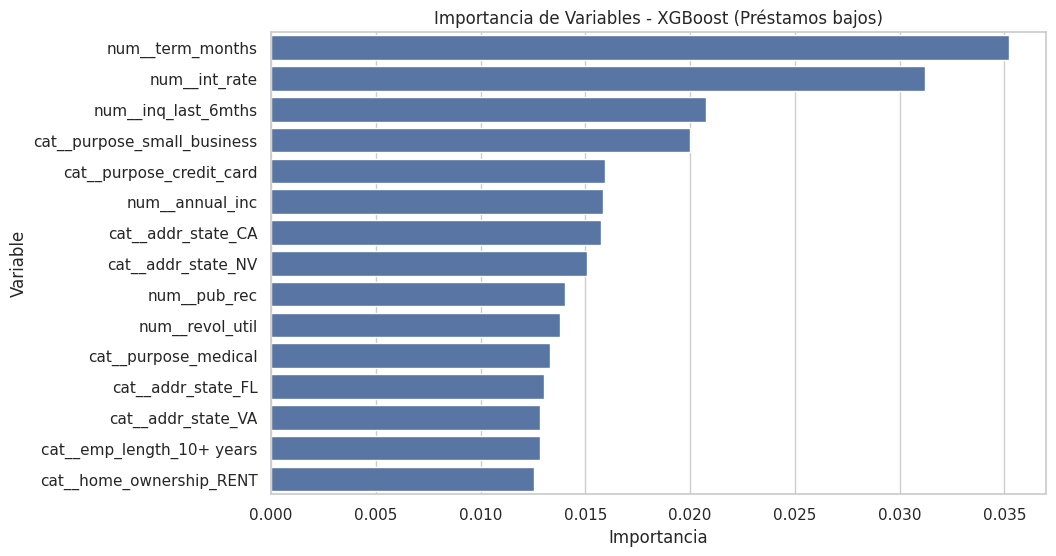

In [71]:
# extraer el modelo del pipeline
model = pipe_xgb_low.named_steps["model"]

# obtener importancias
importances = model.feature_importances_

# crear dataframe
feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
})

# ordenar
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# tomar top 15
top_features = feature_importance.head(15)

# gráfico
plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Importance", y="Variable")
plt.title("Importancia de Variables - XGBoost (Préstamos bajos)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [72]:
# Extraer el modelo XGBoost del pipeline
model = pipe_xgb_low.named_steps["model"]

# Obtener importancias
importances = model.feature_importances_

# Crear dataframe con nombres de variables
feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
})

# Ordenar de mayor a menor
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Mostrar
print(feature_importance)

                       Variable  Importance
1              num__term_months    0.035227
2                 num__int_rate    0.031234
7           num__inq_last_6mths    0.020744
45  cat__purpose_small_business    0.019976
35     cat__purpose_credit_card    0.015936
..                          ...         ...
60           cat__addr_state_IA    0.000000
63           cat__addr_state_IN    0.000000
73           cat__addr_state_MS    0.000000
69           cat__addr_state_ME    0.000000
88           cat__addr_state_SD    0.000000

[98 rows x 2 columns]


In [73]:
print(feature_importance.head(20))

                             Variable  Importance
1                    num__term_months    0.035227
2                       num__int_rate    0.031234
7                 num__inq_last_6mths    0.020744
45        cat__purpose_small_business    0.019976
35           cat__purpose_credit_card    0.015936
4                     num__annual_inc    0.015865
52                 cat__addr_state_CA    0.015759
80                 cat__addr_state_NV    0.015103
10                       num__pub_rec    0.014025
12                    num__revol_util    0.013813
41               cat__purpose_medical    0.013334
57                 cat__addr_state_FL    0.013023
92                 cat__addr_state_VA    0.012851
16          cat__emp_length_10+ years    0.012832
30           cat__home_ownership_RENT    0.012559
42                cat__purpose_moving    0.012317
78                 cat__addr_state_NJ    0.012244
21            cat__emp_length_6 years    0.012227
33  cat__verification_status_Verified    0.012004


In [74]:
# Extraer modelo
model = pipe_xgb_low.named_steps["model"]

# Importancias
importances = model.feature_importances_

# Dataframe con nombres
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# extraer variable original (antes del segundo "__")
feature_importance["variable_original"] = feature_importance["feature"].apply(
    lambda x: x.split("__")[1].split("_")[0] if "__" in x else x
)

# agrupar
grouped_importance = feature_importance.groupby("variable_original")["importance"].sum()

# ordenar
grouped_importance = grouped_importance.sort_values(ascending=False)

# top 15
top_grouped = grouped_importance.head(15)

print(top_grouped)

variable_original
addr            0.432826
purpose         0.160770
emp             0.111206
home            0.039446
term            0.035227
int             0.031234
verification    0.030560
revol           0.024623
inq             0.020744
annual          0.015865
pub             0.014025
installment     0.011020
mths            0.010959
credit          0.010883
total           0.010604
Name: importance, dtype: float32


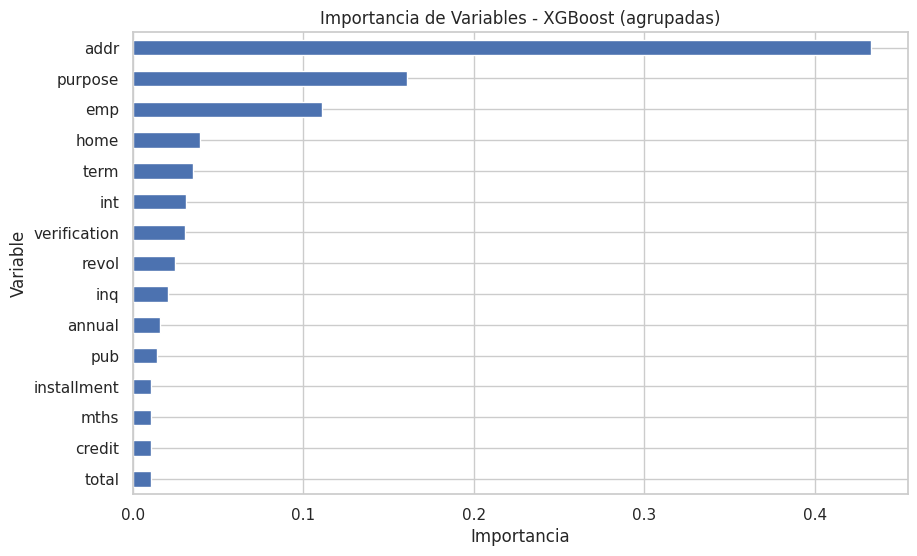

In [75]:
plt.figure(figsize=(10,6))

top_grouped.sort_values().plot(kind="barh")

plt.title("Importancia de Variables - XGBoost (agrupadas)")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

**<h2>PRÉSTAMOS ALTOS</h2>**

<h3>REGRESIÓN LOGÍSTICA</h3>

In [76]:
# Pipeline
pipe_log_high = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# Entrenar
pipe_log_high.fit(X_train_high, y_train_high)

# Predicciones
y_pred_log_high = pipe_log_high.predict(X_test_high)
y_proba_log_high = pipe_log_high.predict_proba(X_test_high)[:,1]

# Métricas
accuracy_log_high = accuracy_score(y_test_high, y_pred_log_high)
precision_log_high = precision_score(y_test_high, y_pred_log_high)
recall_log_high = recall_score(y_test_high, y_pred_log_high)
f1_log_high = f1_score(y_test_high, y_pred_log_high)
roc_auc_log_high = roc_auc_score(y_test_high, y_proba_log_high)

print("Resultados - Regresión Logística (Préstamos altos)")
print("Accuracy:", accuracy_log_high)
print("Precision:", precision_log_high)
print("Recall:", recall_log_high)
print("F1:", f1_log_high)
print("ROC AUC:", roc_auc_log_high)

Resultados - Regresión Logística (Préstamos altos)
Accuracy: 0.6319199057714959
Precision: 0.2770745428973277
Recall: 0.6396103896103896
F1: 0.38665358194308147
ROC AUC: 0.6820143884892086


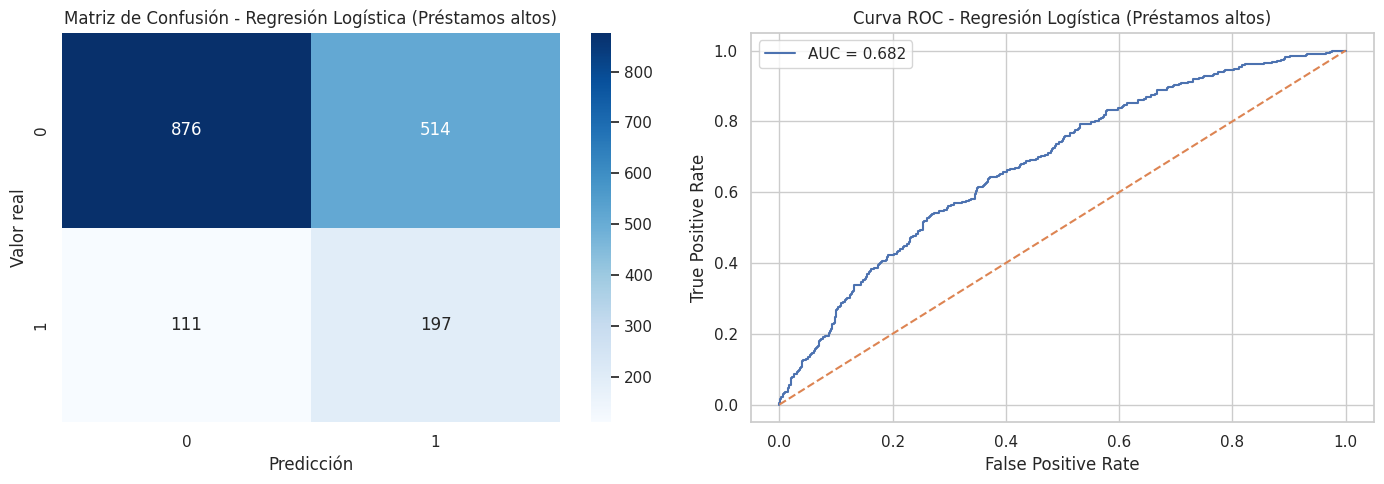

In [77]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test_high, y_pred_log_high)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - Regresión Logística (Préstamos altos)')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test_high, y_proba_log_high)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_log_high:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - Regresión Logística (Préstamos altos)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [78]:
# calcular peso para balancear clases
scale_pos_weight = (y_train_high == 0).sum() / (y_train_high == 1).sum()

# Pipeline
pipe_xgb_high = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

# Entrenar
pipe_xgb_high.fit(X_train_high, y_train_high)

# Predicciones
y_pred_xgb_high = pipe_xgb_high.predict(X_test_high)
y_proba_xgb_high = pipe_xgb_high.predict_proba(X_test_high)[:,1]

# Métricas
accuracy_xgb_high = accuracy_score(y_test_high, y_pred_xgb_high)
precision_xgb_high = precision_score(y_test_high, y_pred_xgb_high)
recall_xgb_high = recall_score(y_test_high, y_pred_xgb_high)
f1_xgb_high = f1_score(y_test_high, y_pred_xgb_high)
roc_auc_xgb_high = roc_auc_score(y_test_high, y_proba_xgb_high)

print("Resultados - XGBoost (Préstamos altos)")
print("Accuracy:", accuracy_xgb_high)
print("Precision:", precision_xgb_high)
print("Recall:", recall_xgb_high)
print("F1:", f1_xgb_high)
print("ROC AUC:", roc_auc_xgb_high)

Resultados - XGBoost (Préstamos altos)
Accuracy: 0.7326266195524146
Precision: 0.271875
Recall: 0.2824675324675325
F1: 0.2770700636942675
ROC AUC: 0.6153858731196862


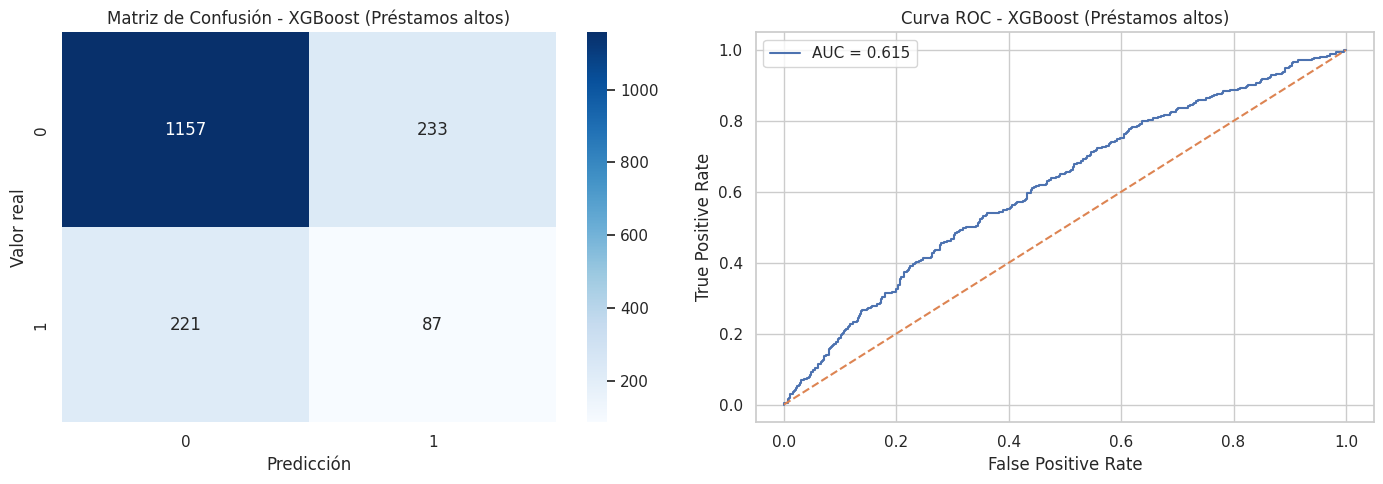

In [79]:
# =========================
# MATRIZ DE CONFUSIÓN + ROC
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test_high, y_pred_xgb_high)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')
axes[0].set_title('Matriz de Confusión - XGBoost (Préstamos altos)')


# Curva ROC
fpr, tpr, _ = roc_curve(y_test_high, y_proba_xgb_high)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_xgb_high:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - XGBoost (Préstamos altos)')
axes[1].legend()

plt.tight_layout()
plt.show()